<a href="https://colab.research.google.com/github/ykitaguchi77/CorneAI/blob/main/Merge%20number%20on%20images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**画像に数字をマージ Merge number on images**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


入力画像の短辺サイズに基づいて文字サイズ・太さ・余白を自動スケーリングし、左上に黒背景付きでファイル名を高視認性で重ねて表示


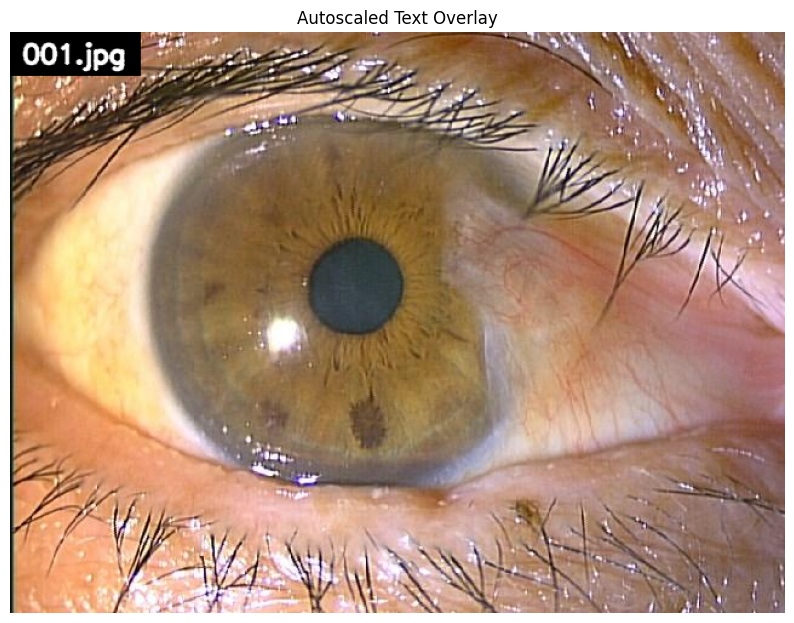

In [27]:
import os
import cv2
import matplotlib.pyplot as plt

# ===== 画像パス =====
image_path = '/content/drive/MyDrive/研究/進行中の研究/角膜スマートフォンAIプロジェクト/前原の100問/maehara100_resized/001.jpg'

# ===== 画像読み込み =====
img = cv2.imread(image_path)
if img is None:
    raise FileNotFoundError(f"画像が読み込めません: {image_path}")

h, w = img.shape[:2]
short_side = min(h, w)

# ===== 表示テキスト =====
text = os.path.basename(image_path)

# ===== 自動スケーリング設定（ここが肝）=====
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = short_side * 0.0015    # ← 画像サイズ依存（約5%相当）
thickness  = max(1, int(font_scale * 3))
padding    = int(font_scale * 15)

# ===== テキストサイズ取得 =====
(text_w, text_h), baseline = cv2.getTextSize(text, font, font_scale, thickness)

# ===== 背景矩形 =====
bg_tl = (0, 0)
bg_br = (text_w + padding * 2, text_h + padding * 2)
cv2.rectangle(img, bg_tl, bg_br, (0, 0, 0), -1)

# ===== テキスト描画 =====
text_org = (padding, padding + text_h)
cv2.putText(
    img,
    text,
    text_org,
    font,
    font_scale,
    (255, 255, 255),
    thickness,
    cv2.LINE_AA
)

# ===== 表示 =====
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Autoscaled Text Overlay')
plt.show()


指定フォルダ内の全画像を読み込み、各画像の短辺サイズに基づいてファイル名を自動スケーリングした白文字＋黒背景で左上に重ね描画し、同じファイル名のまま別フォルダに一括保存。


In [29]:
import os
import cv2

# ===== 入出力フォルダ =====
input_dir  = '/content/drive/MyDrive/研究/進行中の研究/角膜スマートフォンAIプロジェクト/前原の100問/maehara100_resized'
output_dir = '/content/test'
os.makedirs(output_dir, exist_ok=True)

# ===== 対応拡張子 =====
valid_ext = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

# ===== 全画像を処理 =====
for fname in sorted(os.listdir(input_dir)):
    if not fname.lower().endswith(valid_ext):
        continue

    image_path = os.path.join(input_dir, fname)
    out_path   = os.path.join(output_dir, fname)

    img = cv2.imread(image_path)
    if img is None:
        print(f"スキップ（読み込み失敗）: {fname}")
        continue

    h, w = img.shape[:2]
    short_side = min(h, w)

    # ===== 表示テキスト（basename） =====
    text = fname

    # ===== 自動スケーリング設定 =====
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = short_side * 0.0015
    thickness  = max(1, int(font_scale * 3))
    padding    = int(font_scale * 15)

    # ===== テキストサイズ取得 =====
    (text_w, text_h), baseline = cv2.getTextSize(text, font, font_scale, thickness)

    # ===== 背景矩形 =====
    bg_tl = (0, 0)
    bg_br = (text_w + padding * 2, text_h + padding * 2)
    cv2.rectangle(img, bg_tl, bg_br, (0, 0, 0), -1)

    # ===== テキスト描画 =====
    text_org = (padding, padding + text_h)
    cv2.putText(
        img,
        text,
        text_org,
        font,
        font_scale,
        (255, 255, 255),
        thickness,
        cv2.LINE_AA
    )

    # ===== 保存 =====
    cv2.imwrite(out_path, img)
    print(f"保存完了: {out_path}")

print("✅ 全画像の処理が完了しました。")


保存完了: /content/test/001.jpg
保存完了: /content/test/002.jpg
保存完了: /content/test/003.jpg
保存完了: /content/test/004.jpg
保存完了: /content/test/005.jpg
保存完了: /content/test/006.jpg
保存完了: /content/test/007.jpg
保存完了: /content/test/008.jpg
保存完了: /content/test/009.jpg
保存完了: /content/test/010.jpg
保存完了: /content/test/011.jpg
保存完了: /content/test/012.jpg
保存完了: /content/test/013.jpg
保存完了: /content/test/014.jpg
保存完了: /content/test/015.jpg
保存完了: /content/test/016.jpg
保存完了: /content/test/017.jpg
保存完了: /content/test/018.jpg
保存完了: /content/test/019.jpg
保存完了: /content/test/020.jpg
保存完了: /content/test/021.jpg
保存完了: /content/test/022.jpg
保存完了: /content/test/023.jpg
保存完了: /content/test/024.jpg
保存完了: /content/test/025.jpg
保存完了: /content/test/026.jpg
保存完了: /content/test/027.jpg
保存完了: /content/test/028.jpg
保存完了: /content/test/029.jpg
保存完了: /content/test/030.jpg
保存完了: /content/test/031.jpg
保存完了: /content/test/032.jpg
保存完了: /content/test/033.jpg
保存完了: /content/test/034.jpg
保存完了: /content/test/035.jpg
保存完了: /content/test/